#CNN CON ResNet34

In [1]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision import models

print('PyTorch:', torch.__version__)
print('TorchVision loaded')

PyTorch: 2.12.0+cpu
TorchVision loaded


In [4]:
# -----------------------------
# Paths and configuration
# -----------------------------
# Ajusta estas rutas a tu entorno si tus archivos están en otra carpeta.
CSV_PATH = Path('./inferencia.csv')
IMAGE_DIR = Path(r'C:\Users\Alejandro Mondragon\Documents\Tec\Integrador\Imagenes')

TARGET_COL = 'LogMass'
IMAGE_EXT = '.jpg'

IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0
RANDOM_SEED = 42

TRAIN_FRAC = 0.8
VAL_FRAC = 0.1
TEST_FRAC = 0.1

EPOCHS = 25
PATIENCE = 6

LR_HEAD = 1e-3
LR_BACKBONE = 1e-4
WEIGHT_DECAY = 1e-4

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9
print(f'CSV_PATH: {CSV_PATH.resolve()}')
print(f'IMAGE_DIR: {IMAGE_DIR.resolve()}')

CSV_PATH: C:\Users\Alejandro Mondragon\Downloads\inferencia.csv
IMAGE_DIR: C:\Users\Alejandro Mondragon\Documents\Tec\Integrador\Imagenes


In [5]:
# -----------------------------
# Sanity check for the image directory
# -----------------------------
if not IMAGE_DIR.exists():
    print(f'Warning: image directory not found: {IMAGE_DIR.resolve()}')
else:
    n_files = sum(1 for _ in IMAGE_DIR.iterdir())
    print(f'Image directory exists. Total entries: {n_files}')

Image directory exists. Total entries: 10126


In [6]:
# -----------------------------
# Load CSV and keep only rows with an existing image
# -----------------------------
df = pd.read_csv(CSV_PATH)

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

df['image_path'] = df['name'].astype(str).apply(lambda x: str(IMAGE_DIR / f'{x}{IMAGE_EXT}'))
exists_mask = df['image_path'].apply(os.path.exists)

missing = int((~exists_mask).sum())
df = df.loc[exists_mask].reset_index(drop=True)

print(f'Rows in CSV: {len(pd.read_csv(CSV_PATH))}')
print(f'Rows with existing images: {len(df)}')
print(f'Missing images skipped: {missing}')
print(df[['name', TARGET_COL, 'image_path']].head())

Rows in CSV: 10126
Rows with existing images: 10098
Missing images skipped: 0
                name    LogMass  \
0  manga-10001-12701   9.486857   
1  manga-10001-12702   9.727675   
2  manga-10001-12703  10.136514   
3  manga-10001-12704   9.632117   
4  manga-10001-12705  10.113519   

                                          image_path  
0  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
1  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
2  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
3  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  
4  C:\Users\Alejandro Mondragon\Documents\Tec\Int...  


In [7]:
# -----------------------------
# Stratified train / val / test split for regression
# -----------------------------
def stratified_split_regression(dataframe, target_col, frac, seed=42, n_bins=10):
    # Split a dataframe into two parts while keeping the target distribution similar
    # using quantile bins. Returns (left, right).
    if len(dataframe) < 10:
        shuffled = dataframe.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        cut = int(round(len(shuffled) * frac))
        return shuffled.iloc[:cut].reset_index(drop=True), shuffled.iloc[cut:].reset_index(drop=True)

    work = dataframe.copy()
    # Use fewer bins when the sample size is small.
    n_bins = max(2, min(n_bins, len(work) // 5))
    try:
        work['_bin'] = pd.qcut(work[target_col], q=n_bins, duplicates='drop')
    except ValueError:
        shuffled = work.sample(frac=1.0, random_state=seed).reset_index(drop=True)
        cut = int(round(len(shuffled) * frac))
        return shuffled.iloc[:cut].reset_index(drop=True), shuffled.iloc[cut:].reset_index(drop=True)

    rng = np.random.default_rng(seed)
    left_parts = []
    right_parts = []

    for _, group in work.groupby('_bin', observed=True):
        idx = group.index.to_numpy()
        rng.shuffle(idx)

        n_left = int(round(len(idx) * frac))
        n_left = max(1, min(n_left, len(idx) - 1)) if len(idx) > 1 else len(idx)

        left_parts.append(work.loc[idx[:n_left]])
        right_parts.append(work.loc[idx[n_left:]])

    left = pd.concat(left_parts, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    right = pd.concat(right_parts, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    left = left.drop(columns=['_bin'], errors='ignore')
    right = right.drop(columns=['_bin'], errors='ignore')
    return left, right


df = df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

df_train, df_temp = stratified_split_regression(df, TARGET_COL, TRAIN_FRAC, seed=RANDOM_SEED)
df_val, df_test = stratified_split_regression(df_temp, TARGET_COL, 0.5, seed=RANDOM_SEED + 1)

print('Split sizes:', len(df_train), len(df_val), len(df_test))

target_mean = df_train[TARGET_COL].mean()
target_std = df_train[TARGET_COL].std(ddof=0)
target_std = float(target_std) if target_std and not np.isnan(target_std) else 1.0

print('Target mean/std (train only):', target_mean, target_std)

Split sizes: 8078 1010 1010
Target mean/std (train only): 10.161933534466012 0.7171495330628952


In [8]:
# -----------------------------
# Transforms
# For galaxies, flips and rotations are usually safe because orientation is arbitrary.
# -----------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(degrees=180),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [9]:
class GalaxyRegressionDataset(Dataset):
    def __init__(self, dataframe, target_col, image_col='image_path', transform=None, target_mean=None, target_std=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_col = target_col
        self.image_col = image_col
        self.transform = transform
        self.target_mean = float(target_mean) if target_mean is not None else 0.0
        self.target_std = float(target_std) if target_std not in (None, 0) else 1.0

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row[self.image_col]

        with Image.open(img_path) as img:
            img = ImageOps.exif_transpose(img).convert('RGB')
            if self.transform is not None:
                img = self.transform(img)

        y = float(row[self.target_col])
        y = (y - self.target_mean) / self.target_std
        y = torch.tensor(y, dtype=torch.float32)
        return img, y


train_ds = GalaxyRegressionDataset(
    df_train, TARGET_COL, transform=train_transform,
    target_mean=target_mean, target_std=target_std
)
val_ds = GalaxyRegressionDataset(
    df_val, TARGET_COL, transform=eval_transform,
    target_mean=target_mean, target_std=target_std
)
test_ds = GalaxyRegressionDataset(
    df_test, TARGET_COL, transform=eval_transform,
    target_mean=target_mean, target_std=target_std
)

pin_memory = device.type == 'cuda' if 'device' in globals() else False
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

print('DataLoaders ready')

DataLoaders ready


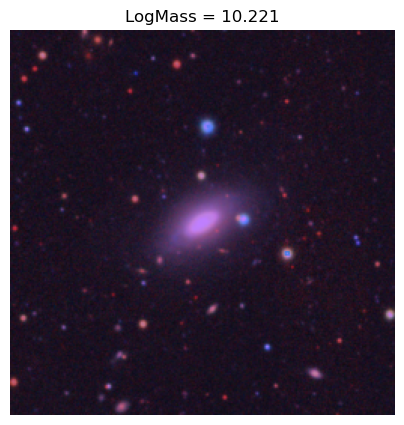

In [10]:
# -----------------------------
# Visualize one sample
# -----------------------------
def denormalize_img(x):
    x = x.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = x * std + mean
    return torch.clamp(x, 0, 1)

idx = np.random.randint(len(test_ds))
img, y = test_ds[idx]
raw_y = y.item() * target_std + target_mean

plt.figure(figsize=(5, 5))
plt.imshow(denormalize_img(img).permute(1, 2, 0))
plt.title(f'{TARGET_COL} = {raw_y:.3f}')
plt.axis('off')
plt.show()

In [11]:
# -----------------------------
# Device
# -----------------------------
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cpu


In [12]:
# -----------------------------
# Model: transfer learning with ResNet-34
# Fine-tune the last residual block + a small regression head.
# -----------------------------
weights = models.ResNet34_Weights.DEFAULT
base_model = models.resnet34(weights=weights)

for p in base_model.parameters():
    p.requires_grad = False

# Unfreeze the higher-level features
for p in base_model.layer3.parameters():
    p.requires_grad = True
for p in base_model.layer4.parameters():
    p.requires_grad = True

in_features = base_model.fc.in_features
base_model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.20),
    nn.Linear(256, 1),
)

for p in base_model.fc.parameters():
    p.requires_grad = True

model = base_model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\Alejandro Mondragon/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|█████████████████████████████████████████████████████████████████████████████| 83.3M/83.3M [00:03<00:00, 24.7MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [13]:
# -----------------------------
# Loss, optimizer, metrics
# -----------------------------
criterion = nn.SmoothL1Loss(beta=0.5)

optimizer = torch.optim.AdamW(
    [
        {'params': model.fc.parameters(), 'lr': LR_HEAD},
        {'params': list(model.layer3.parameters()) + list(model.layer4.parameters()), 'lr': LR_BACKBONE},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = 1 - ss_res / ss_tot
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds_raw = []
    targets_raw = []

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.float32).view(-1, 1)

        out = model(x)
        out = out.detach().cpu().numpy().reshape(-1)
        y = y.detach().cpu().numpy().reshape(-1)

        out_raw = out * target_std + target_mean
        y_raw = y * target_std + target_mean

        preds_raw.extend(out_raw.tolist())
        targets_raw.extend(y_raw.tolist())

    return regression_metrics(targets_raw, preds_raw)

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.float32).view(-1, 1)

        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    return running_loss / len(loader.dataset)

In [14]:
import os

folder_path = r"C:\Users\Alejandro Mondragon\Documents\Tec\Integrador\Imagenes"

# Count all elements (files + folders)
total_elements = len(os.listdir(folder_path))

print("Total elements:", total_elements)

Total elements: 10126


In [15]:
# -----------------------------
# Training loop with early stopping
# -----------------------------
history = {'train_loss': [], 'val_mae': [], 'val_rmse': [], 'val_r2': [], 'lr': []}

best_state = copy.deepcopy(model.state_dict())
best_val_r2 = -np.inf
best_epoch = 0
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_metrics = evaluate(model, val_loader)

    scheduler.step(val_metrics['rmse'])
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_metrics['mae'])
    history['val_rmse'].append(val_metrics['rmse'])
    history['val_r2'].append(val_metrics['r2'])
    history['lr'].append(current_lr)

    if val_metrics['r2'] > best_val_r2:
        best_val_r2 = val_metrics['r2']
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f'Epoch {epoch+1:02d}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} | '
        f'val_MAE={val_metrics["mae"]:.4f} | '
        f'val_RMSE={val_metrics["rmse"]:.4f} | '
        f'val_R2={val_metrics["r2"]:.4f} | '
        f'lr={current_lr:.2e}'
    )

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}. Best epoch was {best_epoch} with val_R2={best_val_r2:.4f}.')
        break

model.load_state_dict(best_state)
print(f'Loaded best model from epoch {best_epoch} with val_R2={best_val_r2:.4f}')

Epoch 01/25 | train_loss=0.3176 | val_MAE=0.2742 | val_RMSE=0.3662 | val_R2=0.7420 | lr=1.00e-03
Epoch 02/25 | train_loss=0.2286 | val_MAE=0.2601 | val_RMSE=0.3569 | val_R2=0.7549 | lr=1.00e-03
Epoch 03/25 | train_loss=0.2137 | val_MAE=0.2445 | val_RMSE=0.3336 | val_R2=0.7859 | lr=1.00e-03
Epoch 04/25 | train_loss=0.2004 | val_MAE=0.3006 | val_RMSE=0.3867 | val_R2=0.7123 | lr=1.00e-03
Epoch 05/25 | train_loss=0.1958 | val_MAE=0.2593 | val_RMSE=0.3463 | val_R2=0.7693 | lr=1.00e-03
Epoch 06/25 | train_loss=0.1903 | val_MAE=0.2432 | val_RMSE=0.3267 | val_R2=0.7947 | lr=1.00e-03
Epoch 07/25 | train_loss=0.1864 | val_MAE=0.2395 | val_RMSE=0.3265 | val_R2=0.7949 | lr=1.00e-03
Epoch 08/25 | train_loss=0.1833 | val_MAE=0.2513 | val_RMSE=0.3303 | val_R2=0.7901 | lr=1.00e-03
Epoch 09/25 | train_loss=0.1791 | val_MAE=0.2341 | val_RMSE=0.3193 | val_R2=0.8039 | lr=1.00e-03
Epoch 10/25 | train_loss=0.1735 | val_MAE=0.2546 | val_RMSE=0.3380 | val_R2=0.7802 | lr=1.00e-03
Epoch 11/25 | train_loss=0.174

In [16]:
# -----------------------------
# Final test evaluation
# -----------------------------
test_metrics = evaluate(model, test_loader)
print('Test metrics:', test_metrics)

Test metrics: {'mae': np.float64(0.2176723881153373), 'rmse': np.float64(0.34225356646282895), 'r2': np.float64(0.780530539760972)}


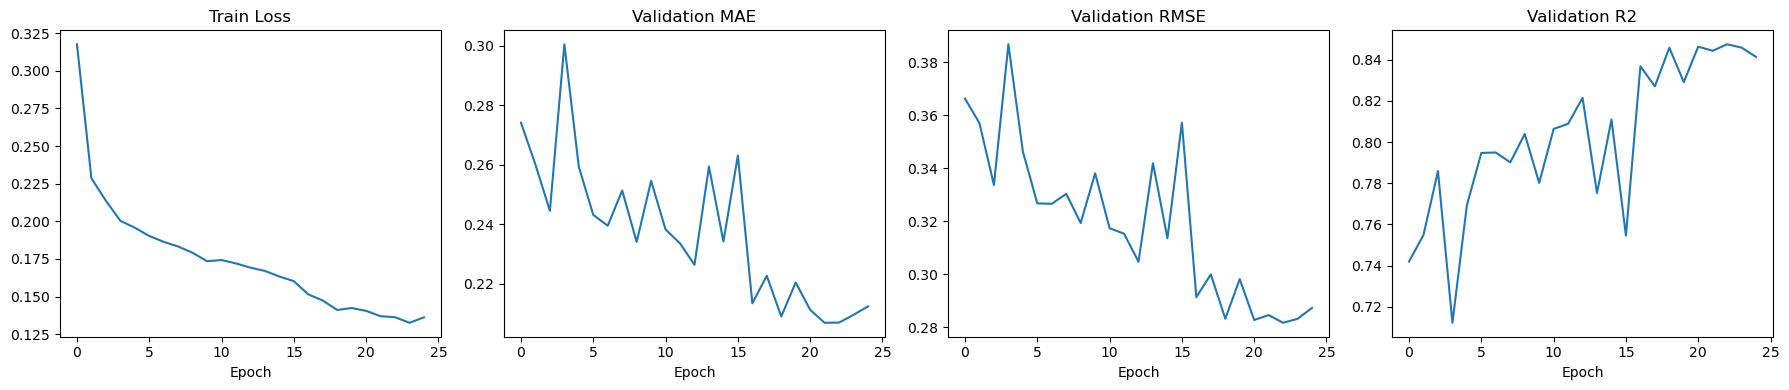

In [17]:
# -----------------------------
# Plot training curves
# -----------------------------
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].plot(history['train_loss'])
ax[0].set_title('Train Loss')
ax[0].set_xlabel('Epoch')

ax[1].plot(history['val_mae'])
ax[1].set_title('Validation MAE')
ax[1].set_xlabel('Epoch')

ax[2].plot(history['val_rmse'])
ax[2].set_title('Validation RMSE')
ax[2].set_xlabel('Epoch')

ax[3].plot(history['val_r2'])
ax[3].set_title('Validation R2')
ax[3].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

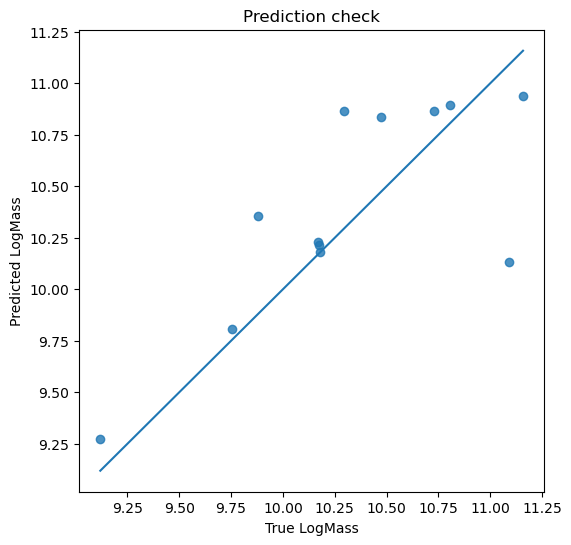

In [18]:
# -----------------------------
# Show predictions vs truth on the whole test set
# -----------------------------
@torch.no_grad()
def predict_loader(model, loader, n_show=12):
    model.eval()
    preds = []
    trues = []

    for x, y in loader:
        x = x.to(device=device, dtype=torch.float32)
        out = model(x).cpu().numpy().reshape(-1)
        y = y.numpy().reshape(-1)

        out = out * target_std + target_mean
        y = y * target_std + target_mean

        preds.extend(out.tolist())
        trues.extend(y.tolist())

    preds = np.array(preds)
    trues = np.array(trues)

    n_show = min(n_show, len(preds))
    plt.figure(figsize=(6, 6))
    plt.scatter(trues[:n_show], preds[:n_show], alpha=0.8)
    lims = [min(trues[:n_show].min(), preds[:n_show].min()), max(trues[:n_show].max(), preds[:n_show].max())]
    plt.plot(lims, lims)
    plt.xlabel('True LogMass')
    plt.ylabel('Predicted LogMass')
    plt.title('Prediction check')
    plt.show()

predict_loader(model, test_loader)

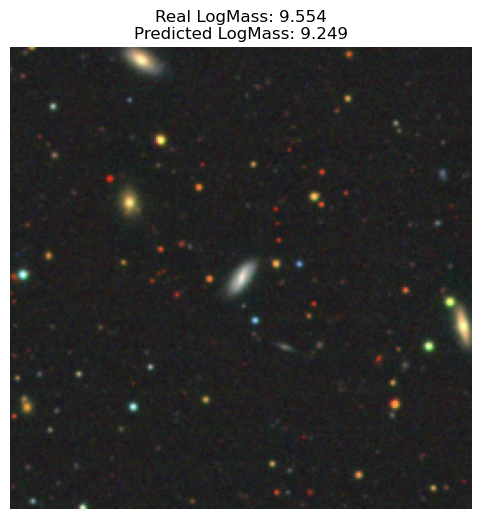

In [20]:
# Put model in evaluation mode
model.eval()

# Random sample from test dataset
idx = np.random.randint(len(test_ds))
img, y = test_ds[idx]

# Move image to device
img_input = img.unsqueeze(0).to(device)

# Predict
with torch.no_grad():
    pred = model(img_input)

# Convert back from normalized scale
real_logmass = y.item() * target_std + target_mean
pred_logmass = pred.item() * target_std + target_mean

# Plot image
plt.figure(figsize=(6,6))
plt.imshow(denormalize_img(img.cpu()).permute(1,2,0))
plt.title(
    f"Real LogMass: {real_logmass:.3f}\n"
    f"Predicted LogMass: {pred_logmass:.3f}"
)
plt.axis('off')
plt.show()